<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana C. Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago A. Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>Edição:</b> 2/2021 | <b>Editora:</b> LTC</div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2021 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Algoritmos e validação de classificadores</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a>

 <hr style="height:2px"> 


## Introdução

Este notebook aborda os modelos múltiplos de classificação, também conhecidos como métodos *ensemble*. Esses modelos fazem a combinação de classificadores para obterem melhor desempenho na tarefa de classificação. Mais especificamente, será explorado o método Floresta Aleatória (RF -- *Random Forest*) [1] que faz a combinação de árvores de decisão. Será comparado o resultado desse método com o resultado de uma árvore de decisão [2].

Os procedimentos serão realizados com a base de dados Seeds [1] que está na pasta `datasets`. Essa base de dados também pode ser encontrada no seguinte link: <https://archive.ics.uci.edu/ml/datasets/seeds>. Ela contém três variedades de trigo: Kama, Rosa e Canadense. Essas três variedades são representadas pelos seguintes atributos: área, perímetro, compacidade, comprimento do grão, largura do grão, coeficiente de assimetria e comprimento do sulco do grão [1]. 

Ao final deste notebook, é esperado que o leitor tenha assimilado os principais conceitos relacionados aos modelos múltiplos de classificação por meio da observação dos resultados obtidos pelo método RF e da sua comparação com os resultados obtidos com uma árvore de decisão. 

Este notebook se refere aos conceitos apresentados nos Capítulos **6 (Métodos Simbólicos)** e **9 (Modelos Múltiplos Preditivos)**.

---
## Recursos necessários

Para este notebook, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/3.1.1/index.html) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.10.0 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`graphviz`](https://pypi.org/project/graphviz/) (versão  0.14.1 ou superior): exibição da árvore de decisão
* [`pydotplus`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 2.0.2 ou superior): exibição da árvore de decisão
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 0.22.1 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial

Será utilizado também o conjunto de dados disponibilizado no diretório `datasets`.

---
## Métodos de Ensemble

Primeiro, vamos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [2]:
# -*- coding: utf-8 -*-

import numpy as np # biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # biblioteca usada para trabalhar com dataframes e análise de dados
import sklearn as skl # sckit-learn
import time # biblioteca usada para calcular o tempo de execucao
import re # biblioteca para expressoes regulares

# importa alguns pacotes do sckit-learn
from sklearn import model_selection 
from sklearn import linear_model # necessario para usar regressão logística
from sklearn import ensemble # necessario para usar os metodos ensemble
from sklearn import naive_bayes # necessario para usar o metodo naive Bayes
from sklearn import tree # necessario para usar arvores de decisao
from sklearn import svm # necessario para usar o metodo SVM
from sklearn import neighbors # necessario para usar o metodo KNN
from sklearn import model_selection # necessario para fazer validacao cruzada
from sklearn import metrics # necessario para obter o desempenho da classificacao

# bibliotecas para geração de gráficos
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import Image
import seaborn as sns

#!pip install graphviz
#!conda install python-graphviz
#!pip install pydotplus
import pydotplus # usada para plotar a arvore de decisao

# executa o arquivo que contém funções auxiliares que serao usadas neste exercício
%run utils.py

print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


Vamos carregar os dados do arquivo e visualizar as suas primeiras amostras. É importante notar que o arquivo original da base de dados não possui título para suas colunas e, por isso, na função `read_csv` do pandas setaremos o parâmetro `header = None`. A separação das colunas no arquivo original é feito por espaços em branco de tamanhos variados e, por isso, setaremos o parâmetro `sep = '\s+'`.

In [3]:
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv( 'datasets/seeds_dataset.txt', sep='\s+', header=None) 

# imprime o dataframe. 
display(df_dataset.head(10))

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,1
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,1


Para facilitar a visualização, vamos nomear as colunas da base de dados com os nomes dos atributos. Depois, vamos substituir o valor das classes pelo nome da variedade de trigo que ela representa: 1 (Kama), 2 (Rosa), 3 (Canadense).

In [4]:
df_dataset.columns = ['area','perimetro','compacidade','compr.Grao','larg.Grao','coef.Assimetria', 'Compr.SulcoGrao', 'classe']

# converte as classes para string
df_dataset['classe'] = df_dataset['classe'].astype(str)

# troca o valor das classe pelo nome da variedade de trigo que ela representa
df_dataset["classe"] = df_dataset["classe"].replace({'1': 'Kama', '2': 'Rosa', '3': 'Canadense'})

# imprime o dataframe. 
display(df_dataset.head(10))

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,Compr.SulcoGrao,classe
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,Kama
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,Kama
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,Kama
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,Kama
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,Kama


Vamos plotar gráficos de dispersão para cada combinação de atributos. 

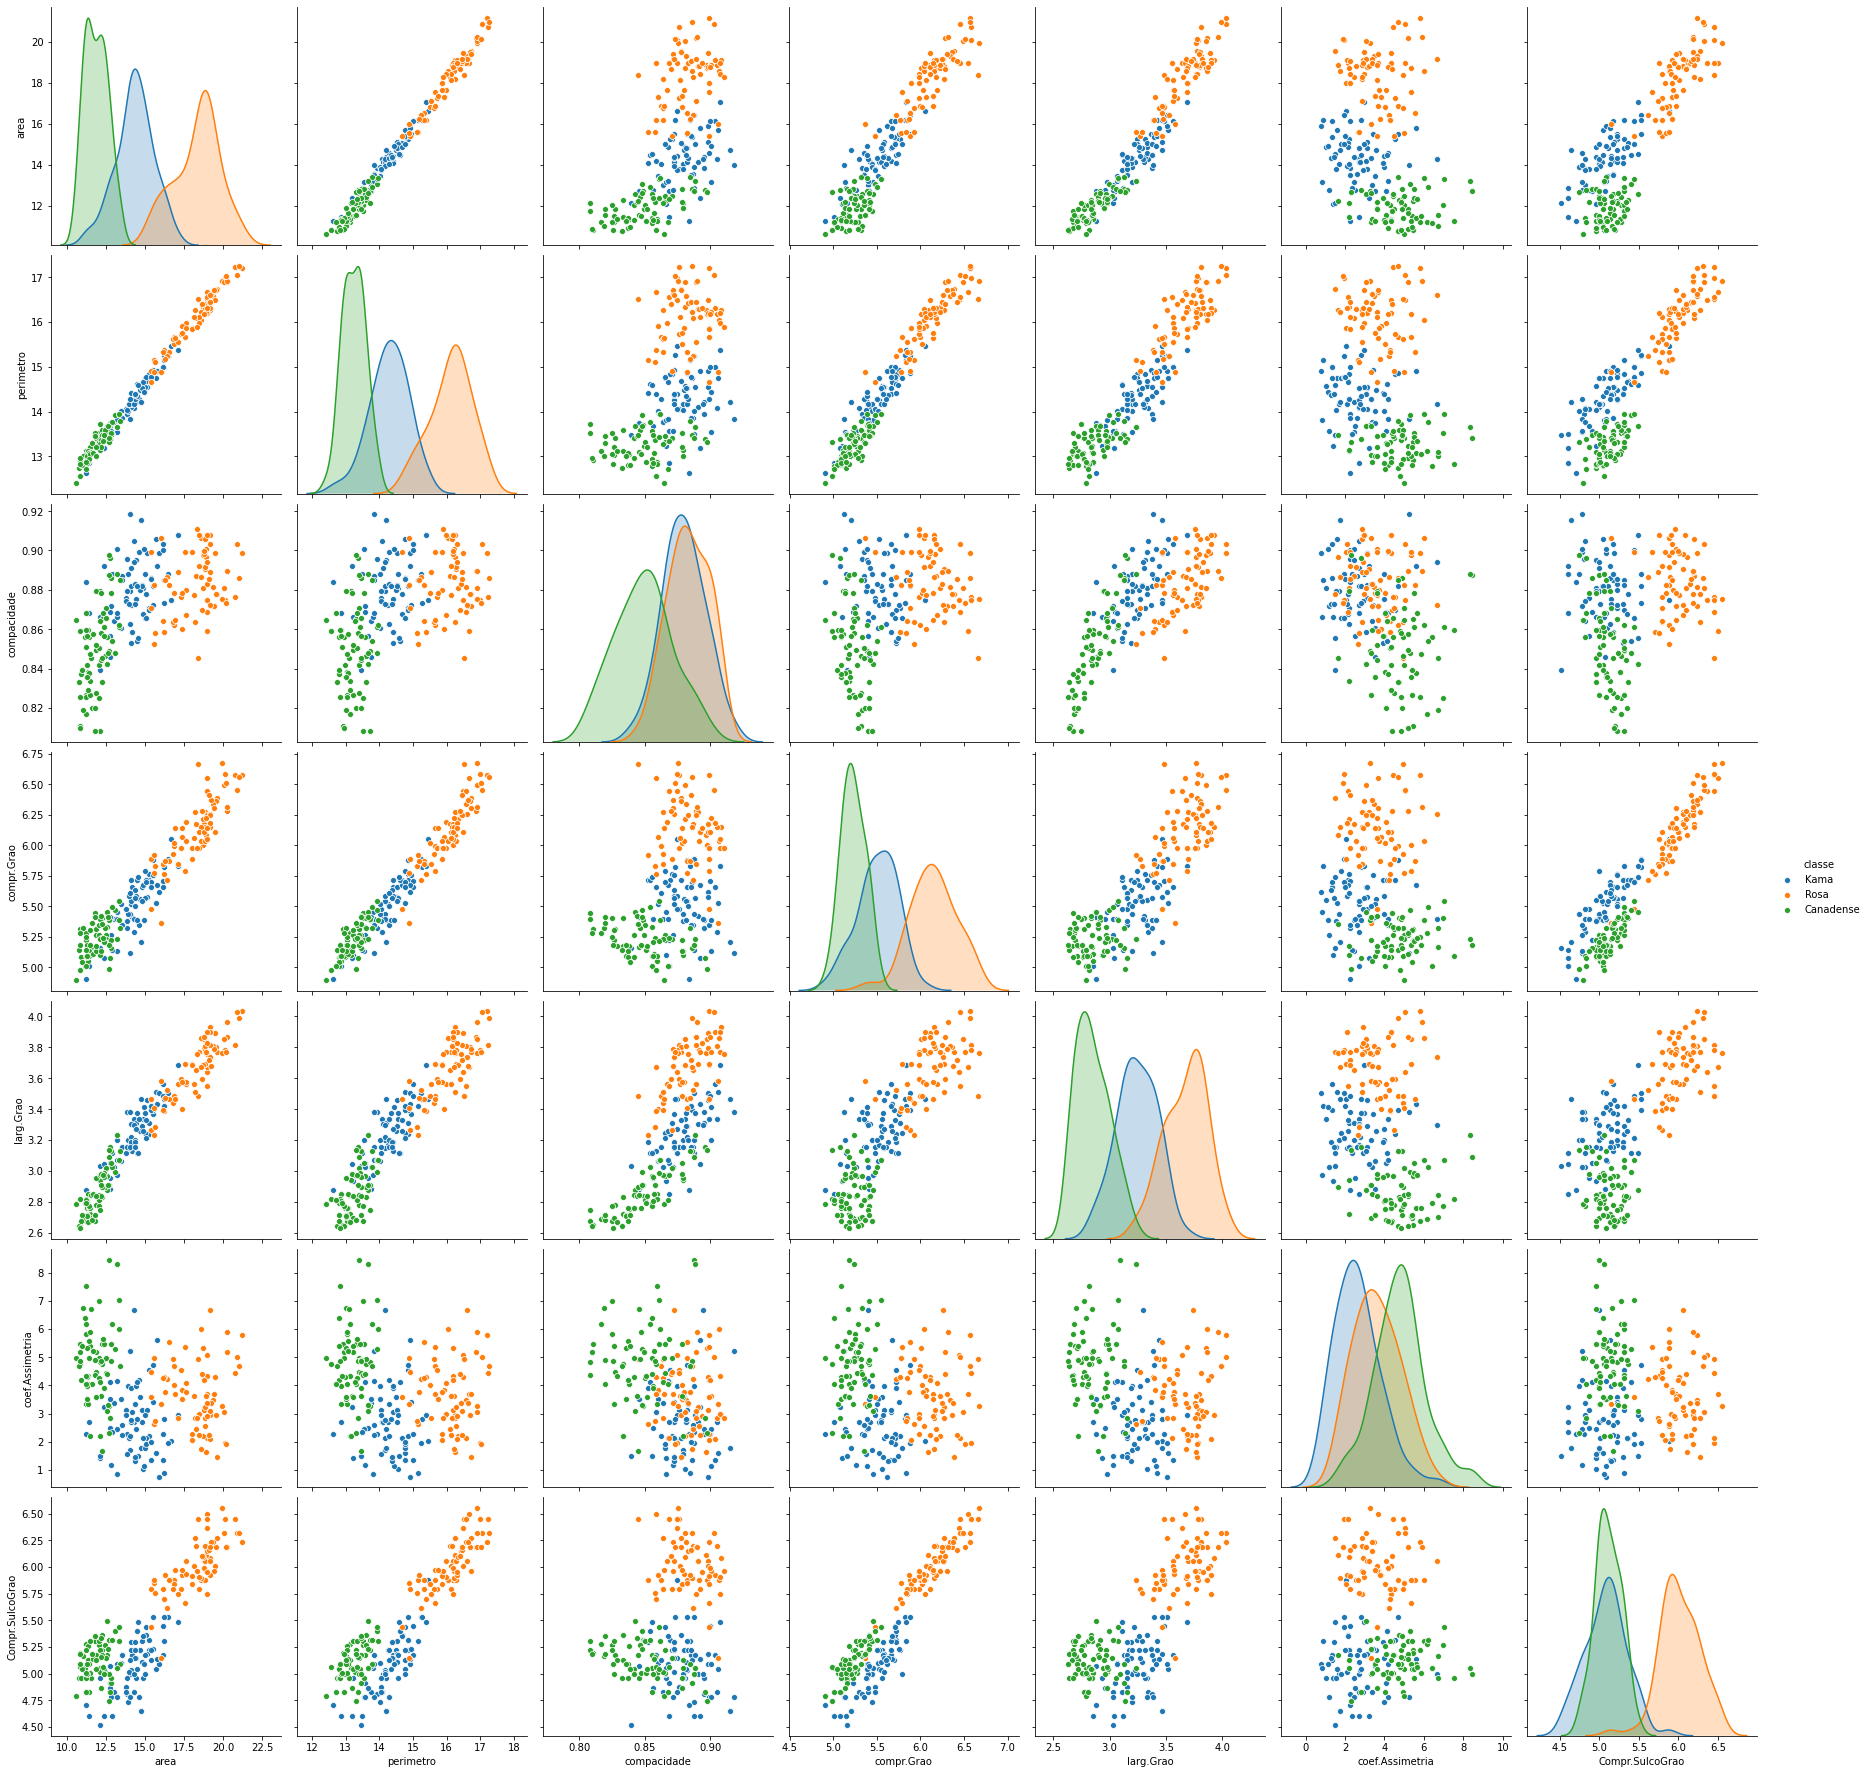

In [5]:
# matriz de gráficos scatter 
sns.pairplot(df_dataset, hue='classe', height=3.5);

# mostra os gráficos usando a função show() da matplotlib
plt.show()

Vamos analisar as principais estatísticas sobre os atributos da base de dados.

In [6]:
# apresenta as principais estatísticas sobre a base de dados
df_detalhes = df_dataset.describe()

display(df_detalhes)

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,Compr.SulcoGrao
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


Pode-se notar pelas informações mostradas acima que a escala dos valores de alguns atributos é bastante diferente. Por exemplo, o valor médio do atributo *área* é 14.8, enquanto o valor médio do atributo *compacidade* é apenas 0.87. Para alguns métodos de classificação, como aqueles baseados em distância, seria necessário realizar a normalização dos dados. No entanto, como esse notebook empregará apenas os métodos Floresta aleatória e árvores de decisão, essa etapa não é necessária.

Vamos analisar a distribuição das classes.

Kama         70
Canadense    70
Rosa         70
Name: classe, dtype: int64

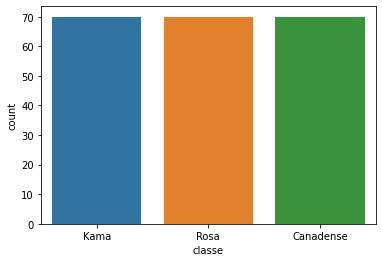

In [7]:
display( df_dataset['classe'].value_counts() )

# cria um gráfico de barras com a frequência de cada classe
sns.countplot(x="classe", data=df_dataset)

# plota o gráfico
plt.show()

Conforme mostrado acima, existem 70 amostras de cada uma das três classes da base dados.

A seguir, os dados são armazenados dentro de uma matriz e as classes dentro de um vetor. As cinco primeiras linhas da matriz de dados e do vetor de classes serão exibidos.

In [8]:
# obtem os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset.iloc[:, 0:-1].values 

# obtem os valores da ultima coluna e guarda em um vetor Y
Y = df_dataset.iloc[:, -1].values 

# classes
classes = np.unique(Y)

# imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

# imprime os nomes das classes
print('\nClasses:', classes)

'X:'

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

Y: ['Kama' 'Kama' 'Kama' 'Kama' 'Kama']

Classes: ['Canadense' 'Kama' 'Rosa']


Agora, os dados de treino e teste serão divididos de forma estratificada. Neste notebook, usaremos a validação *holdout* estratificada por motivos didáticos. No entanto, sempre que for possível, é mais recomendado usar a validação cruzada K-*fold*, pois é mais robusta. Para mais detalhes, consulte o Capítulo 10 (Avaliação de Modelos Preditivos). 

In [9]:
# divide os dados em treino e teste
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=2020)

# retorna os índices de treino e teste
train_index, test_index = list( cv.split(X, Y) )[0]

# retorna as partições de treino e teste de acordo com os índices
X_train, X_test = X[train_index, :], X[test_index, :];
Y_train, Y_test = Y[train_index], Y[test_index];

print('Dimensão dos dados de treinamento:', X_train.shape)
print('Dimensão dos dados de teste:', X_test.shape)

Dimensão dos dados de treinamento: (147, 7)
Dimensão dos dados de teste: (63, 7)


Existem diversos métodos múltiplos de classificação, mas neste exercício iremos usar a **Floresta Aleatória**. Um dos parâmetros que devemos setar para esse método é o **n_estimators** que refere-se à quantidade de Árvores de Decisão que ele irá combinar. Como esse parâmetro pode influenciar bastante nos resultados, iremos fazer a escolha do seu valor usando uma busca em grade. Os valores que iremos testar, começam em 10 e vão até 200, variando de 20 em 20. Para mais detalhes sobre esse método de classificação, consulte o Capítulo 9 (Modelos Múltiplos Preditivos).

In [10]:
# inicializa o classificador com os parâmetros default do Scikit
RFClassifier = skl.ensemble.RandomForestClassifier( random_state=2020 ) 

# número de árvores de decisão que serão testadas na busca em grade {10,30,50,...,200}
param_grid = {'n_estimators': np.arange(10,201,20)} 

# validação cruzada que sera usada na busca em grade
cvGrid = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3)

# inicia a busca em grade 
RFClassifier = skl.model_selection.GridSearchCV(RFClassifier, cv=cvGrid, param_grid=param_grid, scoring = 'f1_macro')

print('Classificador inicializado com sucesso')

Classificador inicializado com sucesso


Agora, podemos treinar o método de classicação na partição de treinamento e testar na partição de teste. Para imprimir o relatório de desempenho, iremos usar a função auxiliar (`relatorioDesempenho()`) que se encontra no arquivo `utils.py`.

In [11]:
# inicia um timer para analisar o tempo de treinamento e teste
startTime = time.time() 
        
# treina o classificador com os dados de treinameto
RFClassifier.fit(X_train, Y_train) 
   
# classifica os dados de teste
Y_pred = RFClassifier.predict(X_test) 

# calcula o tempo consumido no treinamento e no teste
timeExperiment = time.time() - startTime
        
# calcula as medidas de desempenho
resultados_RF = relatorioDesempenho(Y_test, Y_pred, classes, imprimeRelatorio=True)

print( '\n\tTempo (segundos): %1.5f' %timeExperiment)

# acrescenta o tempo aos resultados
resultados_RF.update({'timeExperiment': timeExperiment})


	Revocacao   Precisao   F-medida   Classe
	1.000       0.840      0.913      Canadense
	0.810       1.000      0.895      Kama
	1.000       1.000      1.000      Rosa
	------------------------------------------------
	0.937       0.947      0.936      Média macro
	0.937       0.937      0.937      Média micro

	Acuracia: 0.937

	Tempo (segundos): 1.94130


Vamos dar uma olhada nos parâmetros obtidos pela busca em grade.

In [12]:
# obtem o melhor classificador encontrado na busca em grade
RFClassifier_best = RFClassifier.best_estimator_
 
print('\nQtd. de Árvores de Decisão escolhida na busca em grade')
print('Parâmetro: ', RFClassifier.best_params_['n_estimators'], '-- Score: ', "{0:.3f}".format(RFClassifier.best_score_))

print("\nMacro F-medida obtida para cada parametro testado na busca em grade:")
print()
means = RFClassifier.cv_results_['mean_test_score']
for mean, params in zip(means, RFClassifier.cv_results_['params']):
    print("n_estimators = %d -- Macro F-medida = %0.3f" % (params['n_estimators'],mean))


Qtd. de Árvores de Decisão escolhida na busca em grade
Parâmetro:  110 -- Score:  0.888

Macro F-medida obtida para cada parametro testado na busca em grade:

n_estimators = 10 -- Macro F-medida = 0.846
n_estimators = 30 -- Macro F-medida = 0.865
n_estimators = 50 -- Macro F-medida = 0.865
n_estimators = 70 -- Macro F-medida = 0.865
n_estimators = 90 -- Macro F-medida = 0.865
n_estimators = 110 -- Macro F-medida = 0.888
n_estimators = 130 -- Macro F-medida = 0.888
n_estimators = 150 -- Macro F-medida = 0.888
n_estimators = 170 -- Macro F-medida = 0.865
n_estimators = 190 -- Macro F-medida = 0.865


Vamos criar uma função que recebe um classificador como entrada e plota a árvore de decisão gerada. Vamos usar essa função para plotar a primeira árvore de decisão da melhor Floresta aleatória retornada na busca em grade. 


Primeira árvore de decisão


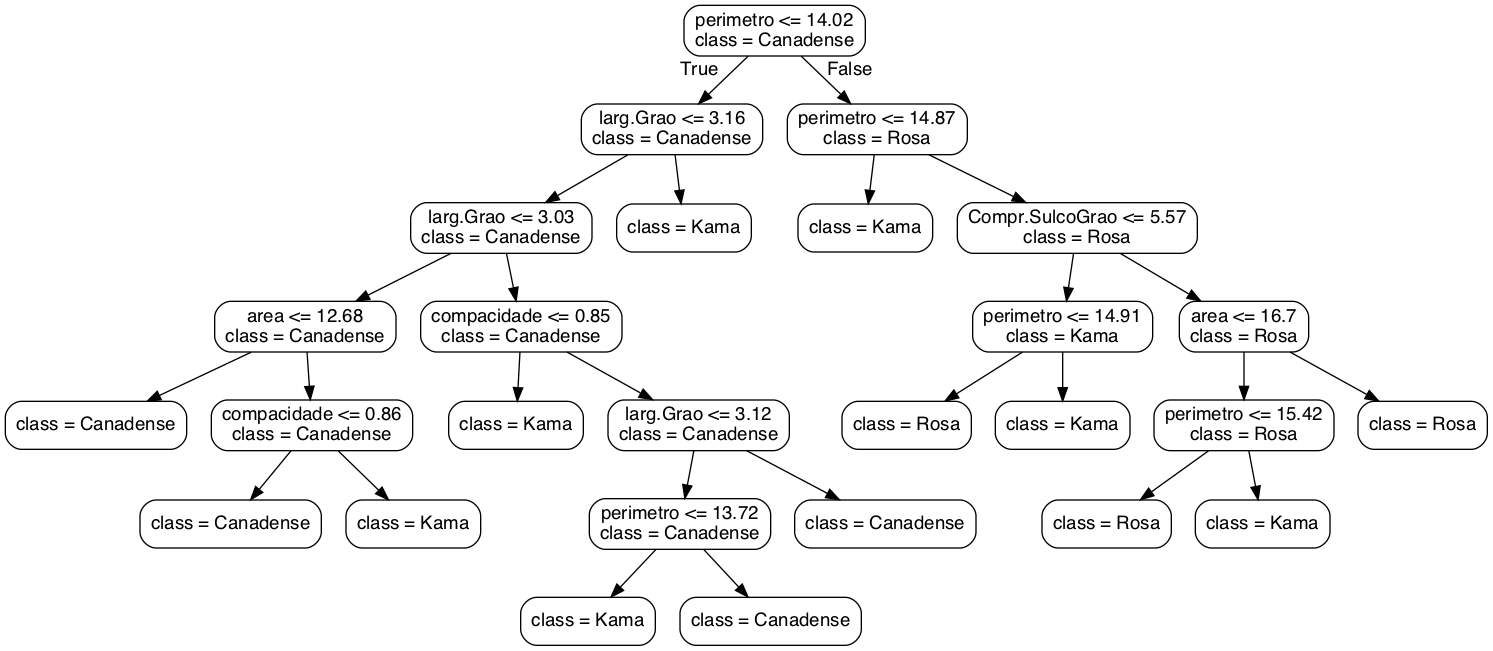

In [14]:
%matplotlib inline

def plota_arvore(classifier, df_dataset, classes):
    
    # define o plote
    dot_data = tree.export_graphviz(classifier, feature_names=df_dataset.columns[0:-1],  
                                    class_names=classes,rounded=True, proportion=False, 
                                    precision=2, filled=False)

    graph = pydotplus.graph_from_dot_data(dot_data).to_string()

    # modifica as informacoes dos nos
    graph = re.sub('(\\\\ngini = [0-9].[0-9]+)(\\\\nsamples = [0-9]+)(\\\\nvalue = \[[0-9]+, [0-9]+, [0-9]+\])', '', graph)
    graph = re.sub('(gini = [0-9].[0-9]+)(\\\\nsamples = [0-9]+)(\\\\nvalue = \[[0-9]+, [0-9]+, [0-9]+\])\\\\n', '', graph)

    # desenha o grafo
    graph = pydotplus.graph_from_dot_data(graph)

    # exibe o grafo
    display(Image(graph.create_png()))
    
    
print('\nPrimeira árvore de decisão')
plota_arvore(RFClassifier_best.estimators_[0], df_dataset, classes)

Vamos imprimir a segunda árvore de decisão da melhor Floresta aleatória retornada na busca em grade.


Segunda árvore de decisão


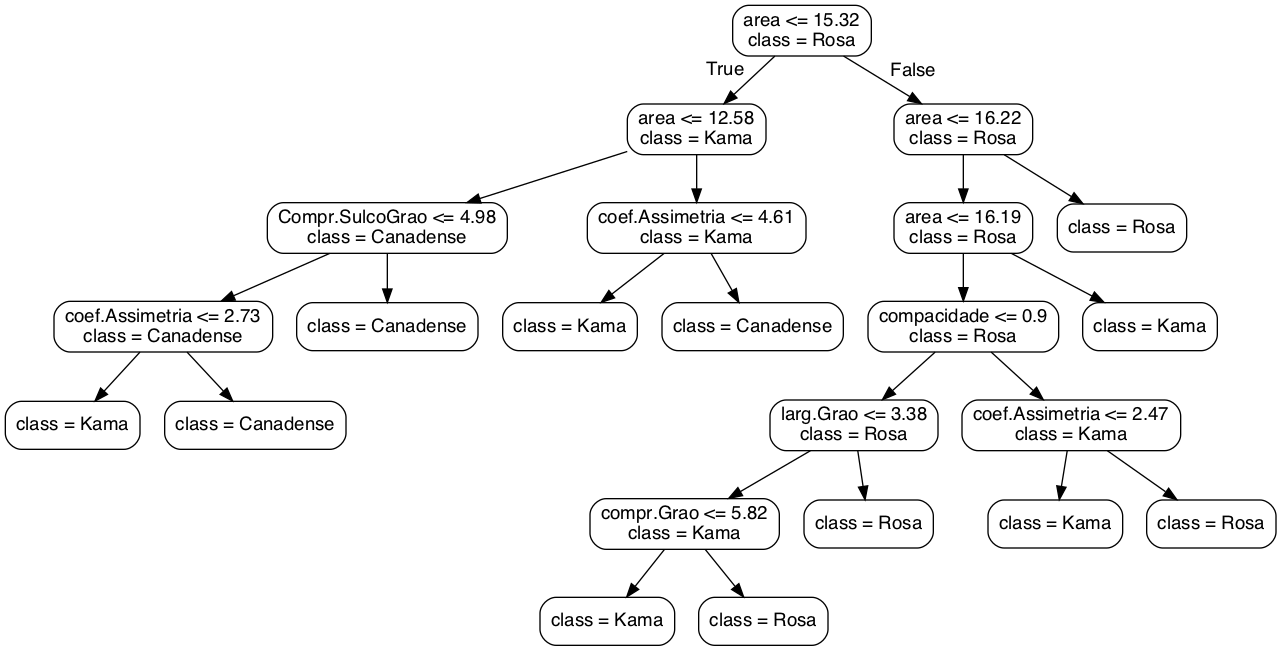

In [15]:
print('\nSegunda árvore de decisão')
plota_arvore(RFClassifier_best.estimators_[1], df_dataset, classes)

Agora, vamos fazer o treino e teste de uma árvore de decisão simples para comparar com o resultado obtido pela floresta aleatória. Como o método Árvore de decisão não possui nenhum parâmetro muito sensível, não faremos nenhum ajuste fino de parâmetros. Detalhes sobre o método Árvore de decisão são oferecidos no Capítulo 6 (Métodos Simbólicos).

In [16]:
# inicia a arvore de decisao
DTClassifier = skl.tree.DecisionTreeClassifier(random_state = 2020)

# inicia um timer para analisar o tempo de treinamento e teste
startTime = time.time() 
        
# treina o classificador com os dados de treinameto
DTClassifier.fit(X_train, Y_train) 
   
# classifica os dados de teste
Y_pred = DTClassifier.predict(X_test) 

# calcula o tempo consumido no treinamento e no teste
timeExperiment = time.time() - startTime
        
# obtem as medidas de desempenho
resultados_DT = relatorioDesempenho(Y_test, Y_pred, classes, imprimeRelatorio=True)

print( '\n\tTempo (segundos): %1.5f' %timeExperiment)

# acrescenta o tempo aos resultados
resultados_DT.update({'timeExperiment': timeExperiment})


	Revocacao   Precisao   F-medida   Classe
	0.952       0.769      0.851      Canadense
	0.667       0.933      0.778      Kama
	1.000       0.955      0.977      Rosa
	------------------------------------------------
	0.873       0.886      0.869      Média macro
	0.873       0.873      0.873      Média micro

	Acuracia: 0.873

	Tempo (segundos): 0.00594


Vamos imprimir a árvore de decisão gerada. 


Árvore de decisão


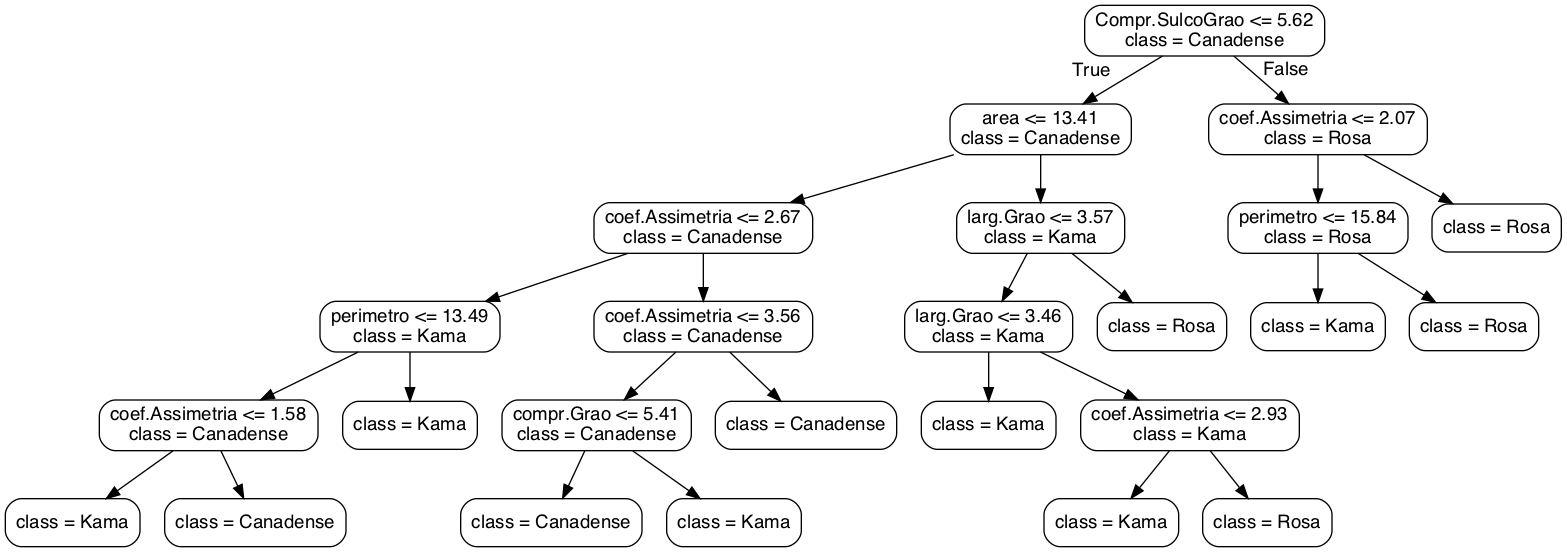

In [17]:
print('\nÁrvore de decisão')
plota_arvore(DTClassifier, df_dataset, classes)

Agora, vamos comparar os resultados da Árvore de decisão com a Floresta aleatória. 

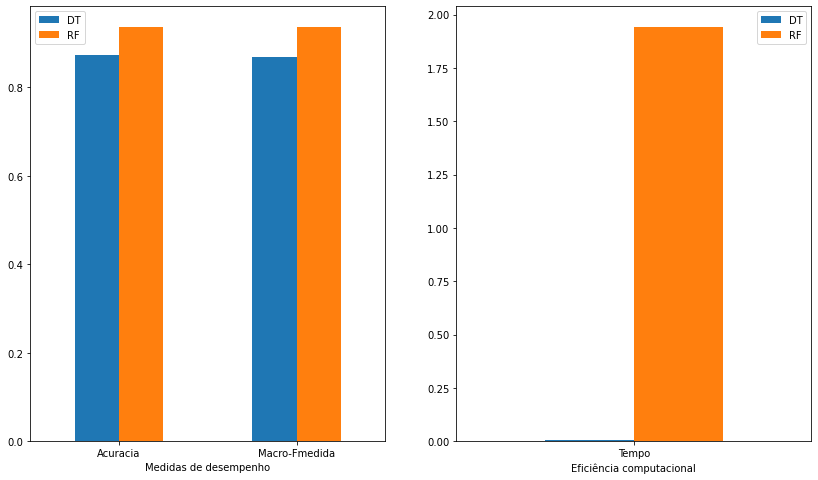

In [18]:
# cria um dicionario  
resultados_medidas = {'Medidas de desempenho':['Acuracia', 'Macro-Fmedida'], 
                        'DT':[resultados_DT['acuracia'], 
                              resultados_DT['fmedida_macroAverage']], 
                        
                        'RF':[resultados_RF['acuracia'],
                              resultados_RF['fmedida_macroAverage']]}

resultados_tempo = {'Eficiência computacional':['Tempo'], 
                        'DT': [resultados_DT['timeExperiment']], 
                        
                        'RF':[resultados_RF['timeExperiment']]}

# cria um dataframe com as medidas de desempenho de cada metodo 
df_medidas = pd.DataFrame(resultados_medidas)
df_tempo = pd.DataFrame(resultados_tempo)

# seta a coluna como indice
df_medidas.set_index("Medidas de desempenho", inplace = True)
df_tempo.set_index("Eficiência computacional", inplace = True)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2,  figsize=(14,8))
                       
# cria um gráfico de barras 
df_medidas.plot.bar(rot=0, ax=ax1)

# cria um gráfico de barras 
df_tempo.plot.bar(rot=0, ax=ax2)

# exibe o gráfico
plt.show()

Pelos gráficos mostrados acima, é possível observar que o método Floresta aleatória obteve os melhores resultados. Porém, pelo fato de ter feito a combinação de várias árvores de decisão, seu custo computacional é bem superior ao custo de gerar uma única árvore.

---
## Conclusão

Neste notebook, foram abordados os modelos múltiplos de classificação. Foi realizada uma comparação entre o desempenho de uma árvore de decisão e do método Floresta aleatória que faz a combinação de várias árvores de decisão. Foi mostrado que o método de Floresta Aleatória pode obter melhores resultados, porém ao custo de um maior consumo de recursos computacionais. Para obter maiores detalhes teóricos sobre os conceitos abordados, consulte os Capítulos 6 (Métodos Simbólicos) e 9 (Modelos Múltiplos Preditivos).

---
## Referências

[1] M. Charytanowicz, J. Niewczas, P. Kulczycki, P.A. Kowalski, S. Lukasik, S. Zak. A Complete Gradient Clustering Algorithm for Features Analysis of X-ray Images. Information Technologies in Biomedicine, Ewa Pietka, Jacek Kawa (eds.), Springer-Verlag, Berlin-Heidelberg, 2010, pp. 15-24. DOI: [10.1007/978-3-642-13105-9_2](http://dx.doi.org/10.1007/978-3-642-13105-9_2).

[2] L. Breiman, J. Friedman, C. J. Stone, R. A. Olshen, Classification and Regression Trees, CRC Press, Boca Raton, FL, USA, 1984.

[3] R. A. Fisher. The use of multiple measurements in taxonomic problems. Annual Eugenics, 7, Part II, 179-188 (1936). DOI: [10.1111/j.1469-1809.1936.tb02137.x](http://dx.doi.org/10.1111/j.1469-1809.1936.tb02137.x).

---